# Model 3 — Support Vector Machine (SVM)
**Student:** IT25101431 — Nasik.F.M  
**Dataset:** Online Shoppers Purchasing Intention  
**Task:** Binary classification — predict `Revenue` (purchase = 1, no purchase = 0)

A Support Vector Machine finds the boundary (hyperplane) that separates the two classes with the **largest margin**. Using a **kernel** (e.g. RBF), it can learn non-linear boundaries by implicitly mapping data into a higher-dimensional space.
- `C` controls the trade-off between a wide margin and misclassifying training points (small C = wider, softer margin).
- `gamma` (RBF kernel) controls how far the influence of a single training point reaches (large gamma = more complex boundary).

SVM is distance-based, so **feature scaling is essential**.

## 1. Import libraries

In [1]:
import os
import glob
import time
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay)

RANDOM_STATE = 42
BASE = ".." if os.path.exists("../data/raw/online_shoppers_intention.csv") else "."
DATA_PATH = f"{BASE}/data/raw/online_shoppers_intention.csv"
FIG_DIR = f"{BASE}/results/model_visualizations"
OUT_DIR = f"{BASE}/results/outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

## 2. Load the dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df["Revenue"].value_counts(normalize=True).round(3))
df.head()

(12330, 18)
Revenue
False    0.845
True     0.155
Name: proportion, dtype: float64


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Prepare features and target
Same features and same train/test split (`random_state=42`) as the previous models, so results are directly comparable.

In [3]:
df["Weekend"] = df["Weekend"].astype(int)
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"])

categorical_cols = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

## 4. Train / test split (stratified 80 / 20)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape)

(9864, 17) (2466, 17)


## 5. Preprocessing
- Numeric: **StandardScaler** (mean 0, std 1) — required because SVM uses distances between points.
- Categorical: **One-Hot Encoding**.

The scaler is inside the pipeline, so it is fitted only on training data (no leakage).

In [5]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

## 6. Kernel comparison (default settings, balanced class weights)
We first compare the three common kernels to choose the best family before tuning.

In [6]:
kernel_rows = []
for k in ["linear", "poly", "rbf"]:
    m = Pipeline([("prep", preprocess),
                  ("model", SVC(kernel=k, class_weight="balanced", random_state=RANDOM_STATE))])
    t0 = time.time()
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    s = m.decision_function(X_test)
    kernel_rows.append({"Kernel": k, "Accuracy": accuracy_score(y_test, p), "Recall": recall_score(y_test, p),
                        "F1": f1_score(y_test, p), "ROC_AUC": roc_auc_score(y_test, s),
                        "Train time (s)": time.time() - t0})
kernels = pd.DataFrame(kernel_rows).set_index("Kernel").round(4)
kernels

,Accuracy,Recall,F1,ROC_AUC,Train time (s)
Kernel,,,,,
linear,0.8690,0.7304,0.6334,0.9042,6.3745
poly,0.8674,0.6859,0.6157,0.8687,5.6563
rbf,0.8658,0.7461,0.6326,0.8954,4.6727


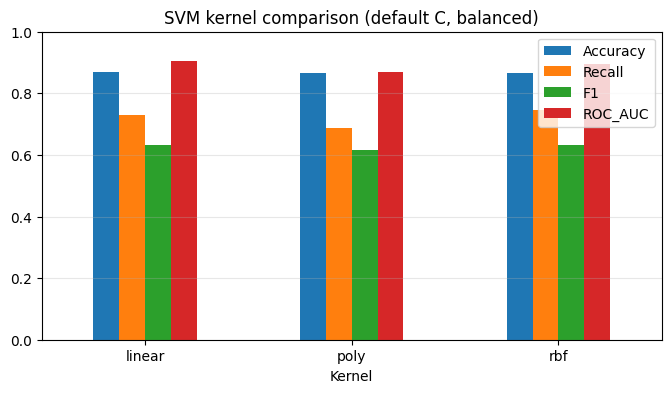

In [7]:
kernels[["Accuracy", "Recall", "F1", "ROC_AUC"]].plot.bar(figsize=(8, 4), rot=0)
plt.ylim(0, 1)
plt.title("SVM kernel comparison (default C, balanced)")
plt.grid(axis="y", alpha=0.3)
plt.savefig(f"{FIG_DIR}/svm_01_kernels.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Baseline model (RBF, no class weighting)

In [8]:
baseline = Pipeline([("prep", preprocess), ("model", SVC(kernel="rbf", random_state=RANDOM_STATE))])
baseline.fit(X_train, y_train)
yb = baseline.predict(X_test)
print("Baseline accuracy:", round(accuracy_score(y_test, yb), 4))
print("Baseline recall  :", round(recall_score(y_test, yb), 4))
print("Baseline F1      :", round(f1_score(y_test, yb), 4))

Baseline accuracy: 0.8869
Baseline recall  : 0.466
Baseline F1      : 0.5606


Without class weighting, the SVM favours the majority class and misses many buyers (low recall).

## 8. Hyperparameter tuning with GridSearchCV (5-fold stratified CV, scoring = F1)

In [9]:
pipe = Pipeline([("prep", preprocess), ("model", SVC(kernel="rbf", random_state=RANDOM_STATE))])
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1],
    "model__class_weight": [None, "balanced"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 4))

Best params: {'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 0.01}
Best CV F1 : 0.6574


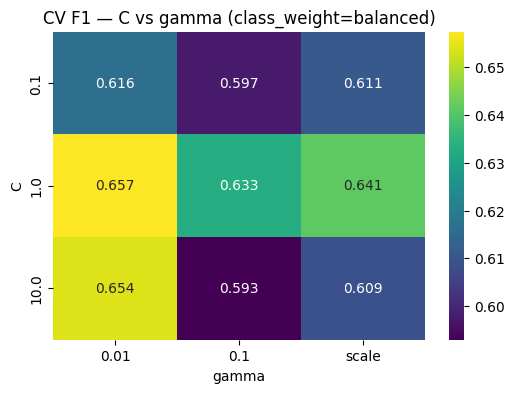

In [10]:
cvres = pd.DataFrame(grid.cv_results_)
bal = cvres[cvres["param_model__class_weight"] == "balanced"]
heat = bal.pivot_table(index="param_model__C", columns=bal["param_model__gamma"].astype(str), values="mean_test_score")
plt.figure(figsize=(6, 4))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis")
plt.title("CV F1 — C vs gamma (class_weight=balanced)")
plt.ylabel("C"); plt.xlabel("gamma")
plt.savefig(f"{FIG_DIR}/svm_02_grid_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Final model
The best settings are refitted with `probability=True` so the model can output purchase probabilities (needed for ROC-AUC, the threshold analysis and comparison with the other models).

In [11]:
best = {k.replace("model__", ""): v for k, v in grid.best_params_.items()}
best_model = Pipeline([("prep", preprocess),
                       ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, **best))])
best_model.fit(X_train, y_train)
print("Number of support vectors:", best_model.named_steps["model"].n_support_.sum(), "of", len(X_train), "training rows")

Number of support vectors: 4436 of 9864 training rows


## 10. Evaluate on the test set

In [12]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

results = {
    "Model": "SVM (RBF)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
}
print(pd.Series(results).drop("Model").astype(float).round(4))
print()
print(classification_report(y_test, y_pred, target_names=["No purchase", "Purchase"]))

Accuracy     0.8727
Precision    0.5685
Recall       0.7382
F1           0.6424
ROC_AUC      0.9025
dtype: float64

              precision    recall  f1-score   support

 No purchase       0.95      0.90      0.92      2084
    Purchase       0.57      0.74      0.64       382

    accuracy                           0.87      2466
   macro avg       0.76      0.82      0.78      2466
weighted avg       0.89      0.87      0.88      2466



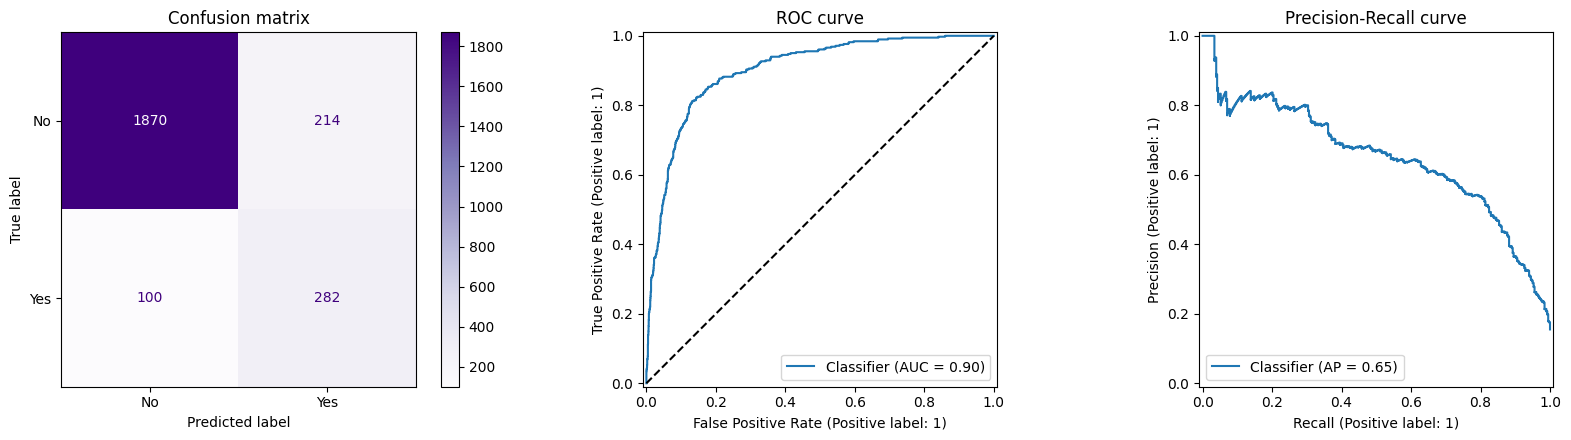

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No", "Yes"], cmap="Purples", ax=ax[0])
ax[0].set_title("Confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax[2])
ax[2].set_title("Precision-Recall curve")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/svm_03_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Feature importance (permutation)
An RBF SVM has no coefficients, so we use **permutation importance**: how much the test F1 drops when each feature is shuffled.

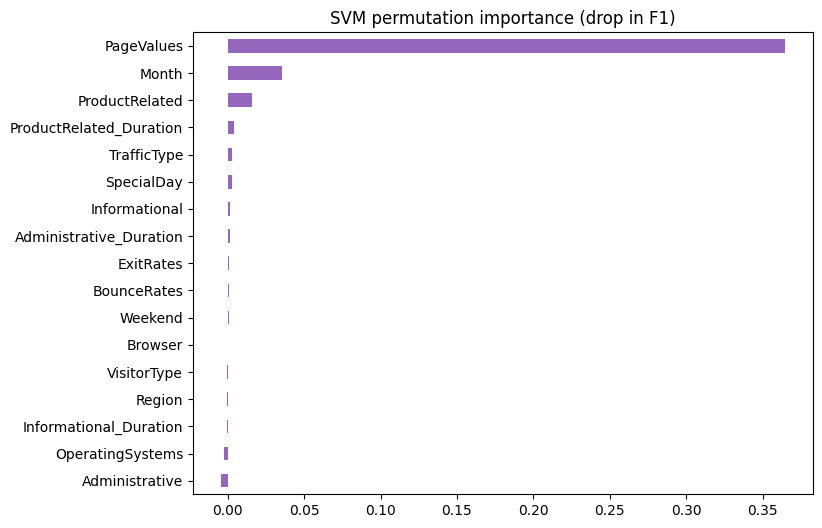

PageValues                 0.3646
Month                      0.0352
ProductRelated             0.0157
ProductRelated_Duration    0.0043
TrafficType                0.0025
SpecialDay                 0.0025
Informational              0.0014
Administrative_Duration    0.0013
ExitRates                  0.0009
BounceRates                0.0008
dtype: float64

In [14]:
perm = permutation_importance(best_model, X_test, y_test, scoring="f1", n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
perm_imp.sort_values().plot.barh(color="tab:purple")
plt.title("SVM permutation importance (drop in F1)")
plt.savefig(f"{FIG_DIR}/svm_04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
perm_imp.round(4).head(10)

## 12. Decision threshold analysis
**Note:** `predict()` uses the SVM decision function (with balanced class weights), while `predict_proba()` uses Platt scaling calibrated to the real class frequencies. So probabilities are more conservative — a probability threshold of about **0.15–0.20** gives the same balance of precision and recall as `predict()`. The table shows how the trade-off changes.

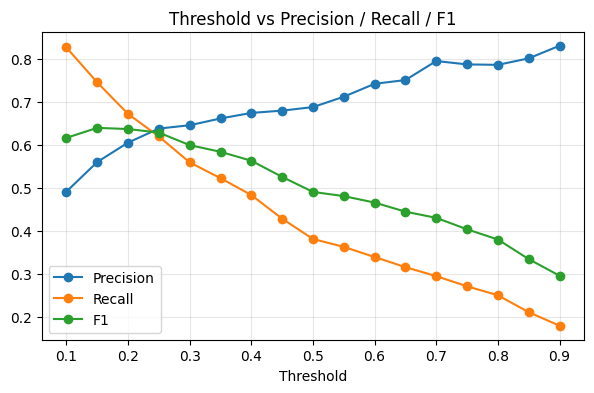

,Threshold,Precision,Recall,F1
0,0.10,0.492,0.827,0.617
1,0.15,0.561,0.746,0.640
2,0.20,0.606,0.673,0.638
3,0.25,0.639,0.620,0.629
4,0.30,0.647,0.560,0.600
5,0.35,0.662,0.524,0.585
6,0.40,0.675,0.484,0.564
7,0.45,0.680,0.429,0.526
8,0.50,0.689,0.382,0.492
9,0.55,0.713,0.364,0.482


In [15]:
th = np.arange(0.1, 0.91, 0.05)
rows = [(t, precision_score(y_test, (y_prob >= t).astype(int), zero_division=0),
         recall_score(y_test, (y_prob >= t).astype(int)),
         f1_score(y_test, (y_prob >= t).astype(int))) for t in th]
thr = pd.DataFrame(rows, columns=["Threshold", "Precision", "Recall", "F1"])
thr.plot(x="Threshold", figsize=(7, 4), marker="o")
plt.title("Threshold vs Precision / Recall / F1")
plt.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/svm_05_threshold.png", dpi=150, bbox_inches="tight")
plt.show()
thr.round(3)

## 13. Comparison with the previous models

In [16]:
files = sorted(glob.glob(f"{OUT_DIR}/model_results_*.csv"))
comp = pd.concat([pd.read_csv(f) for f in files if not f.endswith("_svm.csv")] + [pd.DataFrame([results])],
                 ignore_index=True)
comp = comp.set_index("Model").astype(float).round(4)
comp

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Logistic Regression,0.8719,0.5673,0.7277,0.6376,0.8965
Random Forest,0.8909,0.6348,0.6963,0.6642,0.9197
SVM (RBF),0.8727,0.5685,0.7382,0.6424,0.9025


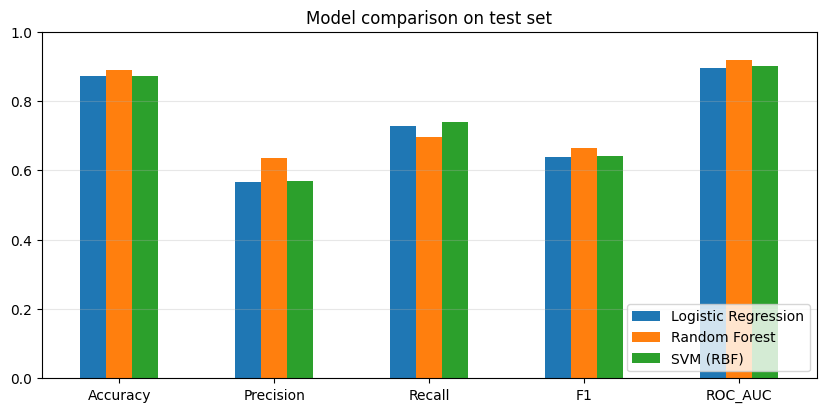

In [17]:
comp.T.plot.bar(figsize=(10, 4.5), rot=0)
plt.ylim(0, 1)
plt.title("Model comparison on test set")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.savefig(f"{FIG_DIR}/svm_06_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Save the model and results

In [18]:
joblib.dump(best_model, f"{OUT_DIR}/svm_model.pkl", compress=3)
pd.DataFrame([results]).to_csv(f"{OUT_DIR}/model_results_svm.csv", index=False)
print("Saved model and results.")

Saved model and results.


## 15. Conclusion
- The RBF kernel was chosen (the linear kernel scored similarly by default, and polynomial was weakest). Tuned settings: **C = 1, gamma = 0.01, class_weight = 'balanced'**.
- Test results: **Accuracy 0.873, Precision 0.569, Recall 0.738, F1 0.642, ROC-AUC 0.903**.
- Class weighting was essential: the unweighted baseline found only 47% of buyers (F1 0.561), while the tuned balanced model finds 74% (F1 0.642).
- Compared with the other models, SVM has the **highest recall so far** (0.738) and is slightly better than Logistic Regression on F1 and ROC-AUC, but below Random Forest (F1 0.664, ROC-AUC 0.920).
- `PageValues` is again the dominant feature, followed by `Month` and `ProductRelated`.
- Drawbacks: SVM needed 4,436 support vectors (45% of training rows), is slower to train than Logistic Regression, and is harder to interpret than linear or tree models.